In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_samples_out, save_cns_fig

In [3]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [4]:
full = {
    "PCAWG" : load_samples_out("PCAWG_samples_fill.tsv"),
    "TCGA_hg19": load_samples_out("TCGA_hg19_samples_fill.tsv"),
    "TRACERx": load_samples_out("TRACERx_samples_fill.tsv"),
}
gaps = {
    "PCAWG" : load_samples_out("PCAWG_samples.tsv"),
    "TCGA_hg19": load_samples_out("TCGA_hg19_samples.tsv"),
    "TRACERx": load_samples_out("TRACERx_samples.tsv"),	
}
colors = {"PCAWG": "C0", "TCGA_hg19": "C1", "TRACERx": "C2", "combined": "gray"}


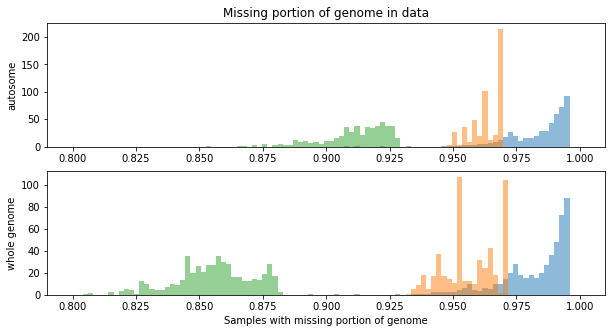

In [5]:
fig, axs = plt.subplots(2, figsize=(10, 5))
bins = np.linspace(.80, 1, 100)
yaxes = ["autosome", "whole genome"]
features = ["cover_het_aut", "cover_het_all"]
for j in range(2):
    for i, (k, v) in enumerate(full.items()):
        axs[j].hist(full[k][features[j]], density=True, bins=bins, alpha=0.5, color=colors[k], label=k)
    axs[j].set_ylabel(yaxes[j])
axs[0].set_title("Missing portion of genome in data")
axs[1].set_xlabel("Samples with missing portion of genome")
save_cns_fig("coverage_all_vs_aut")

PCAWG whole genome 0.9847373731681054
TCGA_hg19 whole genome 0.9638500799305667
TRACERx whole genome 0.9118084721485119
PCAWG filtered 0.9963245841234746
TCGA_hg19 filtered 0.9989453286195814
TRACERx filtered 0.9739585448682551


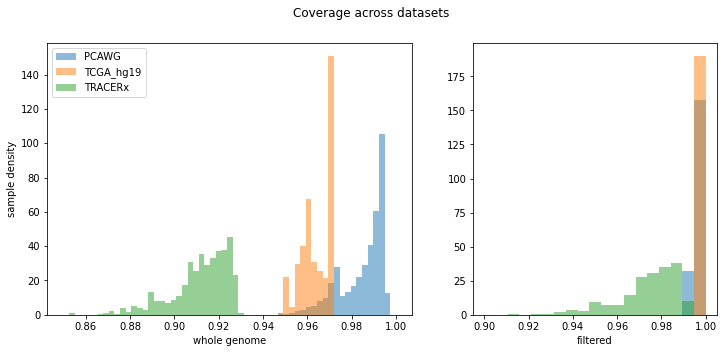

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 2]})
bins = [np.linspace(.85, 1, 60), np.linspace(.90, 1, 20)]
xaxes = ["whole genome", "filtered"]
source = [full, gaps]
for j in range(2):
    for i, (k, v) in enumerate(full.items()):
        axs[j].hist(source[j][k]["cover_het_aut"], density=True, bins=bins[j], alpha=0.5, color=colors[k], label=k)
        print(k, xaxes[j], np.mean(source[j][k]["cover_het_aut"].mean()))
    axs[j].set_xlabel(xaxes[j])
axs[0].legend()
axs[0].set_ylabel("sample density")
plt.suptitle("Coverage across datasets")
save_cns_fig("coverage_whole_vs_gap", fig)
# samples below 0.85
for k, v in full.items():
	print(k, "samples below 0.85", np.sum(full[k]["cover_het_aut"] < 0.85))

# Find regions of TRACERx with missing data

In [114]:
from cns.data_utils import load_cns_out
from cns.process.pipelines import main_aggregate, main_segment, main_fill
from cns.process.segments import regions_select, regions_remove
from cns.process.aggregation import group_samples
from cns.display.plot import fig_bars
from cns.display.label import plot_gaps
import matplotlib.patches as mpatches

In [ ]:
tracerx_cns_df = load_cns_out("TRACERx_cns_fill.tsv", raw=True)

In [84]:
select_regs = regions_select("")
remove_regs = regions_remove("gaps")
hg19_segs = main_segment(tracerx_cns_df, select_regs, remove_regs)
filtered_cns_df = main_aggregate(tracerx_cns_df, hg19_segs, "none")

In [117]:
# # Set the NaNs to 1, rest to 0
labelled_cns_df = filtered_cns_df.copy()
labelled_cns_df.loc[~labelled_cns_df["major_cn"].isna(),"major_cn"] = 0
labelled_cns_df.loc[~labelled_cns_df["minor_cn"].isna(), "minor_cn"] = 0
labelled_cns_df.loc[labelled_cns_df["major_cn"].isna(),"major_cn"] = 1
labelled_cns_df.loc[labelled_cns_df["minor_cn"].isna(), "minor_cn"] = 1

In [93]:
# set the gap regions to 0
filled_cns_df = main_fill(labelled_cns_df, cn_columns=["major_cn", "minor_cn"], print_info=True).fillna(0)
filled_cns_df.head()

No samples provided, creating samples from CNS data.
Adding 73214 missing ends
Filling 394552 gaps.
No missing chromosomes found.
Removed outliers: 0
Merged entries: 1557


,sample_id,chrom,start,end,major_cn,minor_cn,name
0,CRUK0001_SU_T1-R1,chr1,0,10000,0.0,0.0,0
1,CRUK0001_SU_T1-R1,chr1,10000,177417,1.0,1.0,chr1_0
2,CRUK0001_SU_T1-R1,chr1,177417,227417,0.0,0.0,0
3,CRUK0001_SU_T1-R1,chr1,227417,267719,1.0,1.0,chr1_1
4,CRUK0001_SU_T1-R1,chr1,267719,317719,0.0,0.0,0


In [104]:
MB_segs = main_segment(filled_cns_df, select_regs, remove_regs, split_size=3000000)
agg_cns_df = main_aggregate(filled_cns_df, MB_segs, how="mean", print_info=True)

Aggregated into 1739780 CNS.                                        


In [105]:
grouped_df = group_samples(agg_cns_df)

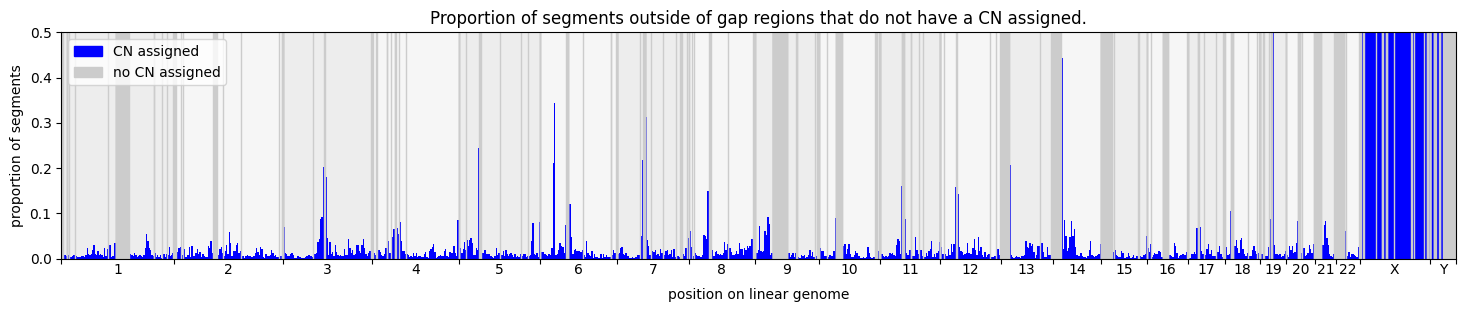

In [116]:
fig, ax = fig_bars(grouped_df, column="major_cn")
plot_gaps(ax, alpha=1, color="#CCCCCC")
ax.set_ylim(0, .5)
ax.set_ylabel("proportion of segments")
ax.set_title("Proportion of segments outside of gap regions that do not have a CN assigned.")
# add legend with two square colors, blue and gray
ax.legend(["no CN assigned", "gap region"], loc="upper right")

cn_assigned_patch = mpatches.Patch(color='blue', label='CN assigned')
no_cn_assigned_patch = mpatches.Patch(color='#CCCCCC', label='no CN assigned')
ax.legend(handles=[cn_assigned_patch, no_cn_assigned_patch], loc="upper left")

save_cns_fig("TRACERx_segments_no_cn")